# Anteproyecto - Computación Avanzada

## Tema: Aprendizaje de refuerzo en sistemas correlacionados en el tiempo usando redes neuronales

### Participantes
- Jefersson Manzanares Fernández
- Esteban Porras Marín

### Objetivos
- Modelar sistemas correlacionados
- Modelar una red neuronal
- Modelar un sistema combinado 

## Marco teórico

### El agente

Es la entidad que toma decisiones dentro del sistema.

El agente:

- Observa el estado del ambiente  
- Ejecuta una acción  
- Recibe una recompensa numérica en función de dicha acción (Reward)  

El objetivo del agente es maximizar la recompensa acumulada a lo largo del tiempo, lo que implica aprender qué acciones son más beneficiosas en distintos contextos. Este proceso de aprendizaje se da mediante prueba y error, donde el agente refuerza aquellas decisiones que conducen a mejores resultados.

El comportamiento del agente se describe mediante una política, que es una función que asigna acciones a estados u observaciones del entorno.

### Red Neuronal

En problemas complejos, donde los estados y acciones son numerosos o continuos, el agente utiliza una red neuronal artificial como herramienta para tomar decisiones. Este enfoque se conoce como deep reinforcement learning.

Una red neuronal es un modelo matemático inspirado en el cerebro humano, compuesto por capas de nodos interconectados. Su función es aproximar funciones complejas, como:

- La política (qué acción tomar en cada estado)  
- O el valor esperado de una acción (qué tan buena es una acción en cierto contexto)  

Durante el entrenamiento, la red neuronal ajusta sus parámetros internos (pesos y sesgos) para mejorar progresivamente las decisiones del agente.

### Ambiente y proceso

El ambiente es el sistema con el que interactúa el agente. El proceso de aprendizaje ocurre mediante un ciclo continuo:

- El agente observa el estado del ambiente  
- Decide una acción usando su política (posiblemente basada en una red neuronal)  
- El ambiente responde con un nuevo estado y una recompensa  
- El agente ajusta su estrategia para mejorar futuras decisiones  

Este ciclo se repite muchas veces durante el entrenamiento, permitiendo al agente desarrollar estrategias óptimas.

## Implementación del proyecto
Modelar un sistema dinámico de poblaciones de peces que interactúan entre sí dentro de un ambiente simulado, incorporando comportamientos estocásticos que reflejan la variabilidad natural de los ecosistemas. En este entorno, un agente basado en aprendizaje por refuerzo toma decisiones sobre cuánto pescar en cada período de tiempo, observando el estado de las poblaciones y recibiendo recompensas en función de la cantidad de peces capturados y la sostenibilidad del sistema. El objetivo del agente no es únicamente maximizar la extracción inmediata, sino desarrollar una política óptima que equilibre la explotación del recurso con la conservación a largo plazo, evitando la extinción de las especies. Para lograrlo, el agente interactúa repetidamente con el ambiente, ajustando su estrategia mediante una red neuronal que le permite aprender patrones complejos y anticipar las consecuencias futuras de sus acciones dentro de un sistema ecológico interdependiente.


## Metodología
Se plantea una metodología progresiva, empezando por modelos sencillos, avanzando hasta sistemas más complejos. Se modela una única población de peces sin considerar efectos estocásticos, utilizando ecuaciones deterministas. Posteriormente, se extiende el modelo a múltiples poblaciones que interactúan entre sí, aún bajo un enfoque determinista, incorporando relaciones ecológicas como competencia o depredación, lo que permite analizar dinámicas más complejas y evaluar la capacidad del agente para tomar decisiones en sistemas interdependientes  Finalmente, se introduce la estocasticidad en el modelo, añadiendo variabilidad aleatoria en procesos como el crecimiento poblacional o las condiciones ambientales, con el fin de aproximarse a escenarios más realistas. 


## Preguntas extra
### ¿Cuánto tiempo dedicarle por semana?
Inicialmente la idea es dedicarle unas 3 horas semanales y conforme avance el proyecto dedicarle más tiempo.

### Cual es el objetivo?
Inicialmente, entender cómo funcionan los modelos neuronales, para posteriormente desarrollar algún caso con un sistema interesante. Y tal vez en el futuro utilizar esta tecnología para desarrollar un paper.

### Cuando pensamos terminarlo?
Depende de cómo avance el proyecto, inicialmente este semestre. Pero si sale algo muy interesante que pueda seguir avanzando se podría extender hasta el siguiente semestre.


## Github del proyecto:
https://github.com/ManzaLord/Reinforcement-Learning

## Referencias:
[1] Lapeyrolerie, M., Chapman, M. S., Norman, K. E. A., & Boettiger, C. (2022). Deep reinforcement learning for conservation decisions. Methods in Ecology and Evolution, 13, 2649–2662. https://doi.org/10.1111/2041-210X.13954 

[2] Stable-Baselines3 Team. (s.f.). Stable-Baselines3 Documentation. https://stable-baselines3.readthedocs.io/en/master/index.html

[3] Farama Foundation. (s.f.). Gymnasium Documentation. https://gymnasium.farama.org


## Ejemplo basico
En este ejemplo se utiliza un ambiente de pesca basico y un agente. La idea principal de este ejemplo es tener una base de la cual partir para el proyecto.

In [11]:
from pesca_1D_env import Pesca1D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [12]:
#Tasa de crecimiento inicial
r = 1

#Inicializa el ambiente
env = Pesca1D(r)

In [13]:
#Inicializa el modelo
agent = PPO("MlpPolicy", env, verbose=1)

#Entrena el modelo
agent.learn(total_timesteps=25000)

#Guarda el modelo
agent.save("ppo_pesca_1D")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 38.5     |
| time/              |          |
|    fps             | 5170     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | 38.5         |
| time/                   |              |
|    fps                  | 1910         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0042372174 |
|    clip_fraction        | 0.014        |
|    clip_range           | 0.2          |
|    en

In [14]:
#Carga el modelo (para evitar correr el entrenamiento todas las veces)
agent = PPO.load("ppo_pesca_1D")

In [15]:
#Cantidad de steps
N = 200

#Reinicia el sistema y obtiene la observación inicial
obs, _ = env.reset()

#Listas para guardar la población y el harvest
poblacion = np.zeros(N)
harvest = np.zeros(N)

for i in range(N):
    #El agente define una accion segun la observación
    action, _ = agent.predict(obs, deterministic=True)

    #Calcula un step del environment segun la acción
    obs, reward, terminated, truncated, _ = env.step(action)
    print(obs)

    #Registra la población de cada paso
    poblacion[i] = env.unnormalize(obs[0])

    #Registra los rewards de cada paso
    harvest[i] = reward

[-0.04522436]
[-0.19259402]
[0.01112087]
[0.06020303]
[-0.1287544]
[0.17954469]
[0.15041569]
[-0.13142288]
[0.01723245]
[-0.1301312]
[-0.14267407]
[-0.08457626]
[-0.07227909]
[-0.16915156]
[-0.0654118]
[-0.17378652]
[-0.013441]
[-0.12686673]
[-0.0801825]
[-0.07221115]
[0.15737422]
[-0.19593497]
[-0.01532668]
[-0.09439076]
[-0.11963672]
[-0.07519459]
[-0.03865941]
[-0.18523736]
[-0.2683122]
[-0.06002808]
[0.04185959]
[-0.08536611]
[-0.04461584]
[0.06666877]
[0.07095895]
[-0.00786838]
[-0.1335045]
[-0.05746282]
[-0.03572389]
[0.04905772]
[0.02606337]
[-0.22072595]
[-0.02207712]
[-0.01921866]
[-0.19472714]
[-0.02936338]
[-0.06840243]
[-0.14852212]
[-0.17807966]
[-0.34451592]
[-0.1814991]
[-0.05054827]
[0.01161589]
[-0.06195029]
[-0.12159438]
[-0.06147068]
[-0.17446424]
[-0.20593342]
[-0.09572861]
[-0.00834507]
[-0.11922894]
[-0.06781525]
[-0.03700645]
[-0.08953789]
[-0.07832914]
[0.11110029]
[-0.09271698]
[7.8240526e-05]
[-0.21726908]
[-0.1491972]
[-0.08490402]
[-0.09498433]
[-0.182698]
[

## Resultados: Evolución temporal de la población y del harvest

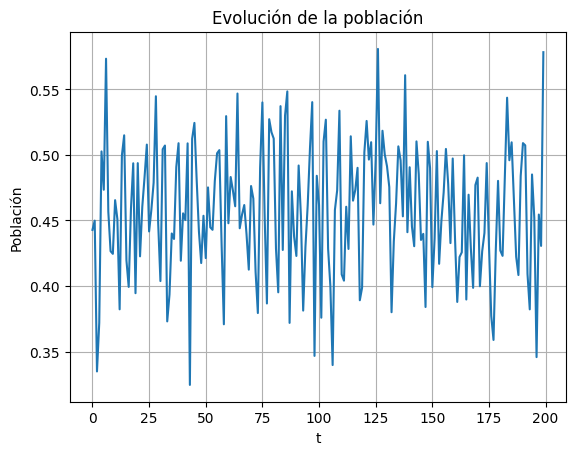

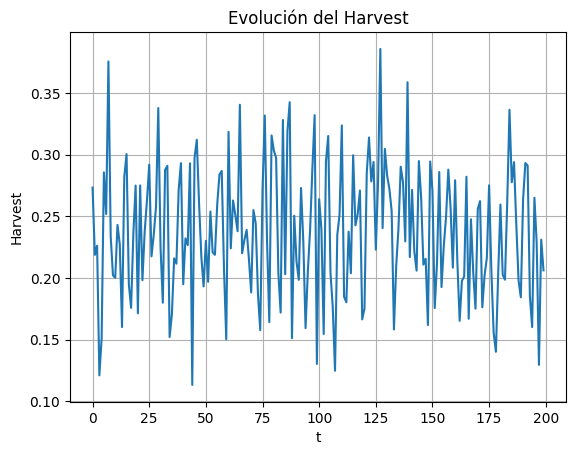

In [9]:
#Grafica la evolución de la población
plt.plot(poblacion)
plt.xlabel("t")
plt.ylabel("Población")
plt.title("Evolución de la población")
plt.grid(True)
plt.show()

#Grafica la evolución del harvest
plt.plot(harvest)
plt.xlabel("t")
plt.ylabel("Harvest")
plt.title("Evolución del Harvest")
plt.grid(True)
plt.show()

## Resultados: Población (Biomasa) en función del harvest (mortalidad por pesca)

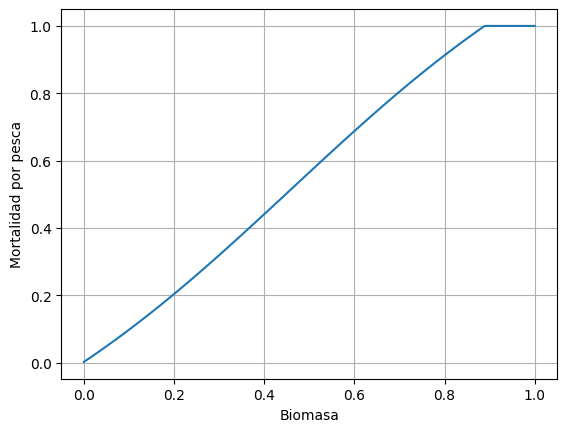

In [10]:
#Define la biomasa como un array en el dominio de [0,1]
M = 100
biomass = np.linspace(0, 1, M)

#Crea un array para guardar las acciones del agente
actions = np.zeros(M)

for i in range(M):
    #Normaliza la observacion al formato necesario de -1 a 1
    obs = np.array([-1 + 2*biomass[i]])

    #El agenre da una accion en funcion de la observacion (cantidad de biomasa)
    action, _ = agent.predict(obs,deterministic=True)

    #Desnormaliza y guarda la accion en el dominio de 0 a 1
    actions[i] = (action[0] +1)/2

#Grafica el resultado
plt.plot(biomass, actions)
plt.xlabel("Biomasa")
plt.ylabel("Mortalidad por pesca")
plt.grid(True)
plt.show()

### Análisis:

La mortalidad aumenta en función de la biomasa, lo cual tiene sentido, ya que si hay más peces, nos podemos permitir pescar más. Otro detalle importante es que, para poblaciones muy bajas, la pesca se detiene por completo, permitiendo al sistema recuperar biomasa hasta alcanzar una población más estable y evitar la extinción completa de la biomasa.